#ML_Lab 4: Improving and Comparing Machine Learning Models

**Name:** _Totaram_

**Roll Number:** _023-24-0244_

**GitHub Repository:** _https://github.com/totaramrathore/machine_learning_practical_

##Part 1 — Decision Tree Baseline Review
Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark everything else in this
lab is measured against.

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same
random_state).
2. Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and
F1-score on the test set. This is your benchmark for the rest of the lab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

customer_ids = df["customerID"].copy()

df = df.drop(columns=["customerID"])

df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include="object").columns.drop("Churn"),
    drop_first=True
)

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [2]:
dt_model = DecisionTreeClassifier(
    max_depth=50,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Decision Tree Results
Accuracy : 0.7260468417317246
Precision: 0.4837837837837838
Recall   : 0.4786096256684492
F1-score : 0.48118279569892475


##Part 2 — Random Forest
A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions. You
already understand individual trees — focus here on how the ensemble differs in behavior, not on re-learning
tree theory.

**Tasks**

3. Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix
random_state). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single
unrestricted Decision Tree.

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Random Forest combines many Decision Trees instead of relying on a single tree. Because the trees are trained using different bootstrapped samples and their predictions are combined, the ensemble usually reduces variance and can generalize better than a single unrestricted Decision Tree.

##Part 3 — Evaluation & Comparison
Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3, then place both
models side by side.

**Tasks**

5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion
matrix.
6. Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab
2/3's finding about class imbalance, which metric matters most here?

In [4]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest Results
Accuracy : 0.7927608232789212
Precision: 0.6366666666666667
Recall   : 0.5106951871657754
F1-score : 0.5667655786350149


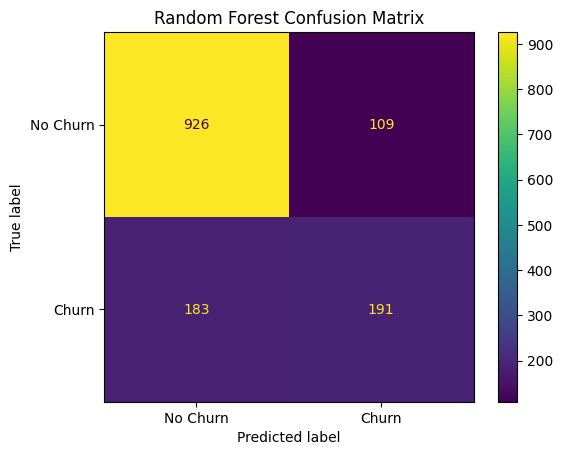

In [5]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

**Interpretation**:

The confusion matrix shows the number of correctly and incorrectly classified customers for both churn classes. In this problem, correctly identifying actual churn customers is particularly important because missing a churner can be more costly than incorrectly flagging a non-churner.

##Part 4 — Cross-Validation
A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the
model k times on different splits, giving a more reliable picture.

**Tasks**

8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain
accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Part 3? Do they change
your view of which model is better, or how confident you are in that conclusion?

In [6]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-score": [dt_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.726047,0.483784,0.478610,0.481183
1,Random Forest,0.792761,0.636667,0.510695,0.566766


**Interpretation**

The Random Forest is compared with the Decision Tree using all four required metrics rather than accuracy alone. The better model is the one that provides stronger generalization, particularly in precision, recall and F1-score. Because the dataset has class imbalance, F1-score and recall for the churn class are more informative than accuracy alone.

##Part 5 — Hyperparameter Tuning
Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-
settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

**Tasks**

10. Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and
define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best
combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [7]:
dt_cv = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree CV")
print("Scores:", dt_cv)
print("Mean :", dt_cv.mean())
print("Std  :", dt_cv.std())

print("\nRandom Forest CV")
print("Scores:", rf_cv)
print("Mean :", rf_cv.mean())
print("Std  :", rf_cv.std())

Decision Tree CV
Scores: [0.50847458 0.50592885 0.48831169 0.4869326  0.50134048]
Mean : 0.49819764012728773
Std  : 0.00894312828794453

Random Forest CV
Scores: [0.5577812  0.5412844  0.52199413 0.56786271 0.56880734]
Mean : 0.551545958874841
Std  : 0.017785836186843828


In [8]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Mean F1": [dt_cv.mean(), rf_cv.mean()],
    "Std F1": [dt_cv.std(), rf_cv.std()]
})

cv_comparison

,Model,Mean F1,Std F1
0,Decision Tree,0.498198,0.008943
1,Random Forest,0.551546,0.017786


**Interpretation**

Five-fold cross-validation evaluates each model on multiple train-validation splits, providing a more reliable estimate than a single train-test split. A higher mean F1-score indicates better average performance, while a lower standard deviation indicates more consistent performance across folds.

##Part 6 — Final Comparison & Feature Importance
Bring every model you've built into one table, choose a final model with evidence, and look inside it to see what
it actually learned.

**Tasks**

13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned
Random Forest — accuracy, precision, recall, F1-score for each.
14. Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best
training score alone is not sufficient justification.
15. Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they
agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

In [9]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validated F1-score:
0.5679133333624713


In [10]:
tuned_rf = grid_search.best_estimator_

tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Random Forest Results")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

Tuned Random Forest Results
Accuracy : 0.7970191625266146
Precision: 0.6506849315068494
Recall   : 0.5080213903743316
F1-score : 0.5705705705705706


**Interpretation**:

Hyperparameter tuning searches for a better Random Forest configuration using cross-validation. The tuned model is then evaluated on the held-out test set using the same metrics as the default Random Forest.

##Part 7 — Kaggle Submission & Conclusion
Wrap up by producing predictions in the shape a real Kaggle competition would expect, and reflect on the lab as
a whole.

**Tasks**

16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and
assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save
it as submission.csv.
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your
Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class
imbalance directly)? Describe it — do not implement it here.

In [11]:
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.726047,0.483784,0.478610,0.481183
1,Random Forest,0.792761,0.636667,0.510695,0.566766
2,Tuned Random Forest,0.797019,0.650685,0.508021,0.570571


In [12]:
importances = tuned_rf.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(5))

tenure                         0.179269
TotalCharges                   0.164776
MonthlyCharges                 0.116738
InternetService_Fiber optic    0.072004
Contract_Two year              0.062823
dtype: float64


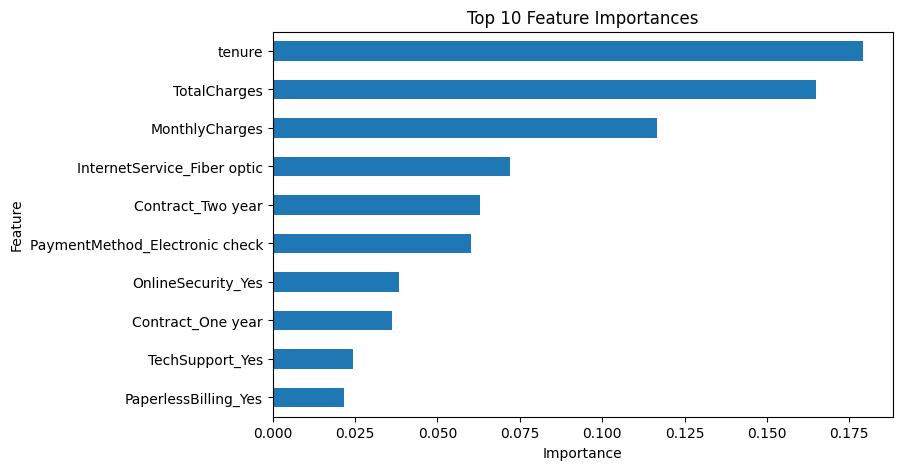

In [13]:
feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Interpretation**

Feature importance shows the relative contribution assigned to each feature by the Random Forest. The top features indicate which customer characteristics were most useful for predicting churn. These important features can be compared with the patterns identified during Lab 2 EDA and the Decision Tree analysis from Lab 3.

**Conclusion**:

In this lab, Decision Tree, Random Forest, and tuned Random Forest models were trained and compared on the Telco Customer Churn dataset. The models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, and five-fold cross-validation to obtain a more reliable performance estimate. The Random Forest approach provides an ensemble-based alternative to a single Decision Tree and can reduce overfitting by combining multiple trees. Hyperparameter tuning was performed using cross-validation to identify a stronger Random Forest configuration. The final model was selected based on its test and cross-validation performance rather than training accuracy alone. If more time were available, class imbalance handling, additional algorithms, and deeper hyperparameter tuning could be explored.